## objectives

This notebook implements a ResNet50-based deep learning model for classifying waste image into six categories

The model will use transfer learning with a ResNet50 backbone
pretrained on ImageNet.

In [10]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf

print("TF version: ", tf.__version__)

TF version:  2.18.0


## 1. Experiment Configuration

In [11]:
IMG_SIZE = (256,256)
BATCH_SIZE = 16
NUM_CLASSES = 6
SEED = 42

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("Class Names: ", CLASS_NAMES)
print("Number of Classes: ", NUM_CLASSES)
print("Image Size: ", IMG_SIZE)
print("Batch Size: ", BATCH_SIZE)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Class Names:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of Classes:  6
Image Size:  (256, 256)
Batch Size:  16


In [12]:
TRAIN_CSV = "../data/processed/train.csv"
VAL_CSV = "../data/processed/validation.csv"
TEST_CSV = "../data/processed/test.csv"

print(os.path.exists(TRAIN_CSV))
print(os.path.exists(VAL_CSV))
print(os.path.exists(TEST_CSV))

True
True
True


In [13]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Training: (9692, 3)
Validation: (2114, 3)
Test: (2091, 3)


In [14]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['relative_path', 'class', 'label']

Validation columns:
['relative_path', 'class', 'label']

Test columns:
['relative_path', 'class', 'label']


In [15]:
train_df["class"].value_counts()

class
glass        1751
trash        1750
paper        1605
plastic      1598
cardboard    1548
metal        1440
Name: count, dtype: int64

In [16]:
sorted(train_df["class"].unique())
print("Number of classes:", train_df["label"].nunique())

Number of classes: 6


In [17]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64


In [18]:
print("Duplicate training rows:", train_df.duplicated().sum())
print("Duplicate validation rows:", val_df.duplicated().sum())
print("Duplicate test rows:", test_df.duplicated().sum())

Duplicate training rows: 0
Duplicate validation rows: 0
Duplicate test rows: 0


In [19]:
train_df.head()

,relative_path,class,label
0,cardboard/cardboard_00001.jpg,cardboard,0
1,cardboard/cardboard_00007.jpg,cardboard,0
2,cardboard/cardboard_00012.jpg,cardboard,0
3,cardboard/cardboard_00013.jpg,cardboard,0
4,cardboard/cardboard_00016.jpg,cardboard,0


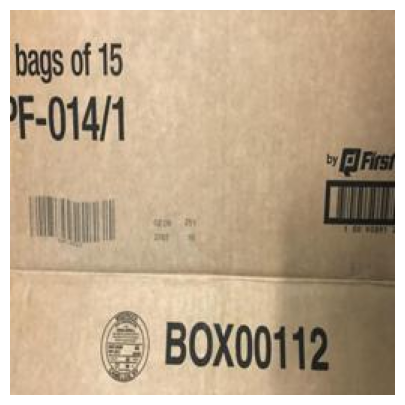

Image size: (256, 256)
Image mode: RGB


In [20]:
image = Image.open("../data/raw/Garbage_Dataset_Classification/images/cardboard/cardboard_00001.jpg")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Image size:", image.size)
print("Image mode:", image.mode)

## 6. ResNet50 Data Preprocessing

In [23]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from pathlib import Path

IMAGE_ROOT = Path("../data/raw/Garbage_Dataset_Classification/images/")

def load_and_preprocess_image(relative_path):
    image_path = IMAGE_ROOT / relative_path

    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)
    image = np.array(image, dtype=np.float32)
    image = preprocess_input(image)
    return image

sample_img = load_and_preprocess_image(train_df.iloc[0]["relative_path"])
print("Shape:", sample_img.shape)
print("Data type:", sample_img.dtype)
print("Min value:", sample_img.min())
print("Max value:", sample_img.max())

Shape: (256, 256, 3)
Data type: float32
Min value: -115.68
Max value: 131.32


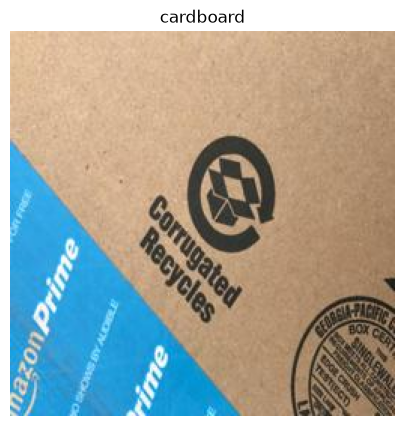

In [25]:
image_path = IMAGE_ROOT / train_df.iloc[1]["relative_path"]

original_image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.axis("off")
plt.title(train_df.iloc[0]["class"])
plt.show()

In [26]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")

In [27]:
def create_dataset(dataframe, training=False):
    paths = dataframe["relative_path"].values
    labels = dataframe["label"].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )
    
    return dataset

In [28]:
def process_image(path, label, training=False):
    
    image_path = tf.strings.join(
        [str(IMAGE_ROOT), "/", path]
    )
    
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(
        image,
        tf.float32
    )
    
    if training:
        image = data_augmentation(image, training=True)
    
    image = preprocess_input(image)
    
    return image, label

In [29]:
def process_image(path, label, training=False):
    
    image_path = tf.strings.join(
        [str(IMAGE_ROOT), "/", path]
    )
    
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(
        image,
        tf.float32
    )
    
    if training:
        image = data_augmentation(image, training=True)
    
    image = preprocess_input(image)
    
    return image, label

In [30]:
train_dataset = create_dataset(
    train_df,
    training=True
)

val_dataset = create_dataset(
    val_df,
    training=False
)

test_dataset = create_dataset(
    test_df,
    training=False
)

In [31]:
train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

In [32]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [33]:
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: (16,)
Label batch shape: (16,)
Image dtype: <dtype: 'string'>
Label dtype: <dtype: 'int64'>
